In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

import seaborn as sns
import matplotlib.pyplot as plt

path = "../data/processed/candor_dataset_clean.csv"
df = pd.read_csv(path)

df["enjoyable_avg"] = (df["how_enjoyable_actor"] + df["how_enjoyable_partner"]) / 2
df["tfo_mean"] = (df["tfo_actor"] + df["tfo_partner"]) / 2
df["tfo_imbalance"] = (df["tfo_actor"] - df["tfo_partner"]).abs()

Code below is to check data.

In [3]:
print(df.shape)
print(df.columns.tolist())
df.head()

(3202, 32)
['call_id', 'actor_id', 'partner_id', 'speech_activity_actor', 'speech_activity_partner', 'tfo_actor', 'tfo_partner', 'overlap_actor', 'overlap_partner', 'pauses_actor', 'pauses_partner', 'how_enjoyable_actor', 'how_enjoyable_partner', 'conversationalist_actor', 'conversationalist_partner', 'my_turn_length_partner', 'my_turn_length_actor', 'your_turn_length_partner', 'your_turn_length_actor', 'conv_length_actor', 'conv_length_partner', 'turn_overlap_gap_actor', 'turn_overlap_gap_partner', 'you_are_competent_partner', 'you_are_competent_actor', 'i_am_good_listener_actor', 'you_are_good_listener_actor', 'i_am_good_listener_partner', 'you_are_good_listener_partner', 'enjoyable_avg', 'tfo_mean', 'tfo_imbalance']


,call_id,actor_id,partner_id,speech_activity_actor,speech_activity_partner,tfo_actor,tfo_partner,overlap_actor,overlap_partner,pauses_actor,...,turn_overlap_gap_partner,you_are_competent_partner,you_are_competent_actor,i_am_good_listener_actor,you_are_good_listener_actor,i_am_good_listener_partner,you_are_good_listener_partner,enjoyable_avg,tfo_mean,tfo_imbalance
0,dd9b5c4a-19cb-4af3-b0e8-f1ce12c5b8fe,5f582002dff3f038d1eb83c4,5e97478f8b670f09dad1fd02,0.453,0.360,0.246,0.158,0.019,0.030,0.198,...,5.0,9.0,9.0,9.0,4.0,6.0,8.0,7.5,0.2020,0.088
1,dd9b5c4a-19cb-4af3-b0e8-f1ce12c5b8fe,5e97478f8b670f09dad1fd02,5f582002dff3f038d1eb83c4,0.360,0.453,0.158,0.246,0.030,0.019,0.134,...,5.0,9.0,9.0,6.0,8.0,9.0,4.0,7.5,0.2020,0.088
2,dbe27cbe-5693-4994-b281-d481a5a4e1f0,5f5ce7f940a2614f6cb6e747,5f4bc3259e842579bf1a8b0a,0.416,0.399,0.330,0.152,0.066,0.058,0.180,...,5.0,9.0,8.0,9.0,8.0,9.0,9.0,7.0,0.2410,0.178
3,dbe27cbe-5693-4994-b281-d481a5a4e1f0,5f4bc3259e842579bf1a8b0a,5f5ce7f940a2614f6cb6e747,0.399,0.416,0.152,0.330,0.058,0.066,0.167,...,6.0,8.0,9.0,9.0,9.0,9.0,8.0,7.0,0.2410,0.178
4,3edbfb87-6b83-4dd0-a4d8-09ca1eba6a3e,5de855017d44177cafe19840,5f7357ed17b7c1054311b85b,0.373,0.414,0.137,0.272,0.014,0.019,0.243,...,5.0,5.0,7.0,7.0,6.0,6.0,6.0,5.0,0.2045,0.135



#### Regression 1
Clustered regression model for how tfo_actor, tfo_partner correlates with partners enjoyment.
Result is in `m1c`.

In [4]:

X1 = sm.add_constant(df[["pauses_actor","tfo_actor", "tfo_partner"]])
y1 = df["how_enjoyable_partner"]

m1 = sm.OLS(y1, X1).fit()
# print(m1.summary())

m1c = sm.OLS(y1, X1).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["call_id"]}
)

#### Regression 2
Clustered regression model for how tfo_mean, tfo_imbalance correlates with average enjoyment.
Result is in `m2c`.

This is the one used in the report.

In [5]:
X2 = sm.add_constant(df["tfo_mean"])
y2 = df["enjoyable_avg"]

m2c = sm.OLS(y2, X2).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["call_id"]}
)

#### Results

Summary prints

In [6]:
print(m1c.summary())
print(m2c.summary())

                              OLS Regression Results                             
Dep. Variable:     how_enjoyable_partner   R-squared:                       0.025
Model:                               OLS   Adj. R-squared:                  0.024
Method:                    Least Squares   F-statistic:                     20.73
Date:                   Tue, 03 Mar 2026   Prob (F-statistic):           3.55e-13
Time:                           14:00:45   Log-Likelihood:                -5873.0
No. Observations:                   3202   AIC:                         1.175e+04
Df Residuals:                       3198   BIC:                         1.178e+04
Df Model:                              3                                         
Covariance Type:                 cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            7

reg-plot: mean fto - avg enjoyment

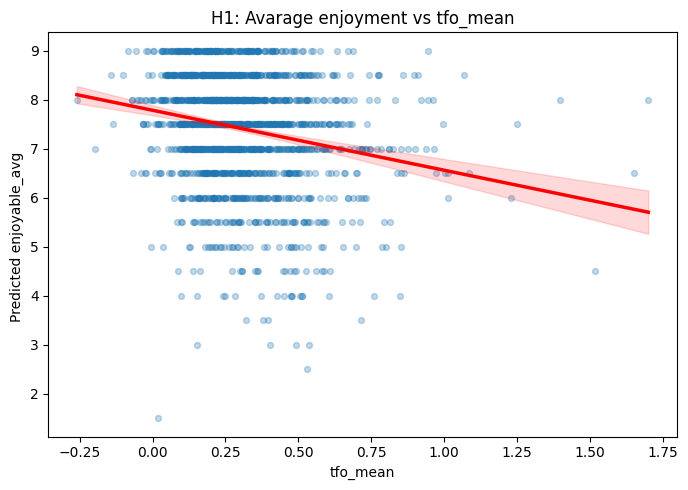

In [7]:
# test
grid = np.linspace(df["tfo_mean"].min(), df["tfo_mean"].max(), 200)
imb_med = df["tfo_imbalance"].median()

Xpred = pd.DataFrame({
    "const": 1.0,
    "tfo_mean": grid,
})

pred = m2c.get_prediction(Xpred).summary_frame(alpha=0.05)

plt.figure(figsize=(7,5))

# valfritt: scatter för kontext
plt.scatter(df["tfo_mean"], df["enjoyable_avg"], s=18, alpha=0.15)

# m2c-linje + CI
plt.plot(grid, pred["mean"], linewidth=2.5, color = "red")
plt.fill_between(grid, pred["mean_ci_lower"], pred["mean_ci_upper"], alpha=0.15, color = "red")

plt.title("H1: Avarage enjoyment vs tfo_mean")
plt.xlabel("tfo_mean")
plt.ylabel("Predicted enjoyable_avg ")
plt.tight_layout()
plt.show()

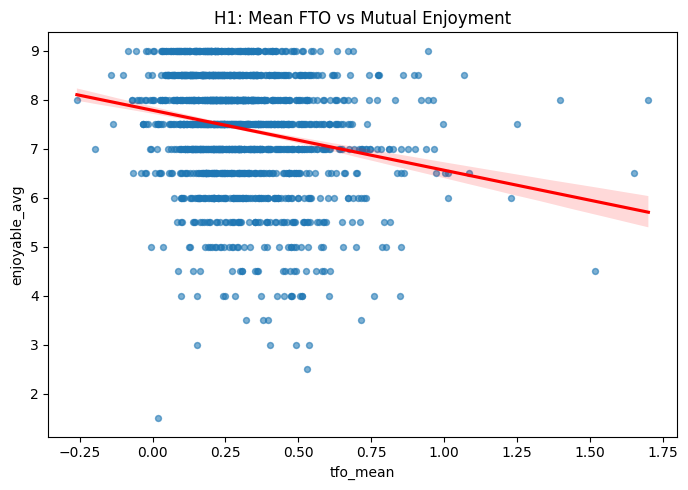

In [8]:
# Same as above but with different package 
plt.figure(figsize=(7,5))
sns.regplot(
    data=df,
    x="tfo_mean",
    y="enjoyable_avg",
    scatter_kws={"alpha": 0.35, "s": 18},
    line_kws={"color": "red"},
    ci=95
)
plt.title("H1: Mean FTO vs Mutual Enjoyment")
plt.xlabel("tfo_mean")
plt.ylabel("enjoyable_avg")
plt.tight_layout()
plt.show()

In [9]:
# Package comparison
print("Seaborn-like slope:")
print(sm.OLS(df["enjoyable_avg"],
             sm.add_constant(df[["tfo_mean"]])
            ).fit().params)

print("m2c slope:")
print(m2c.params)

Seaborn-like slope:
const       7.784630
tfo_mean   -1.223326
dtype: float64
m2c slope:
const       7.784630
tfo_mean   -1.223326
dtype: float64
